In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Ecommerce_Return_Rate_Dataset_500Rows.csv")

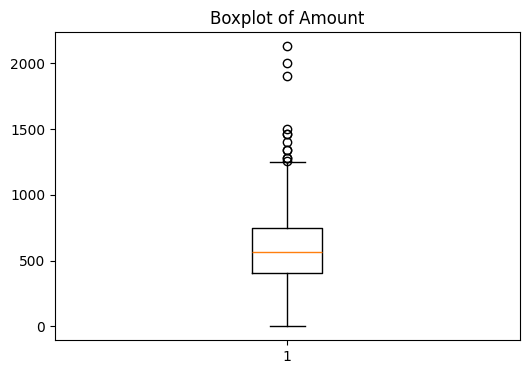

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Amount"].dropna())
plt.title("Boxplot of Amount")
plt.show()

In [ ]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Limit =", lower)
print("Upper Limit =", upper)

Q1 = 406.0
Q3 = 744.0
IQR = 338.0
Lower Limit = -101.0
Upper Limit = 1251.0


In [ ]:
outliers = df[(df["Amount"] < lower) | (df["Amount"] > upper)]

outliers

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22,Return Rate
80,80,408-4069830-3819562,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET394,SET394-KR-NP-XXXL,Set,...,1281.00,Kolkata,WEST BENGAL,700048.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN,0.19
102,102,408-7698765-2294756,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET277,SET277-KR-NP-XXL,Set,...,1338.00,AMBARNATH,MAHARASHTRA,421502.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,0.10
146,146,171-0131752-2560336,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET355,SET355-KR-PP-M,Set,...,1399.00,BARABANKI,UTTAR PRADESH,225001.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,0.14
243,243,408-2759943-9849959,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET363,SET363-KR-NP-XXL,Set,...,1338.00,KOLKATA,WEST BENGAL,700051.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN,0.07
251,251,402-2703790-2816329,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0285,J0285-SKD-M,Set,...,1278.57,JHARIA KHAS,JHARKHAND,828111.0,IN,NaN,False,Easy Ship,NaN,0.52
265,265,171-6655820-6440356,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0008,J0008-SKD-XXL,Set,...,2130.00,MUMBAI,MAHARASHTRA,400101.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN,0.17
299,299,404-7491342-1035558,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0280,J0280-SKD-S,Set,...,1463.00,THANE,MAHARASHTRA,401107.0,IN,NaN,False,NaN,NaN,0.04
318,318,408-3201739-2676310,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET388,SET388-KR-NP-L,Set,...,1260.00,MUMBAI,MAHARASHTRA,400049.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN,0.01
324,324,407-5096970-7475550,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0010,J0010-LCD-L,Set,...,1902.86,HARDOI,UTTAR PRADESH,241001.0,IN,NaN,False,Easy Ship,NaN,0.43
349,349,171-3537751-4007556,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET436,SET436-KR-NP-XXXL,Set,...,1999.00,Nellore,ANDHRA PRADESH,524314.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN,0.04


In [ ]:
len(outliers)

12

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
table = pd.crosstab(df["Category"], df["Status"])
table

Status,Cancelled,Shipped,Shipped - Delivered to Buyer,Shipped - Rejected by Buyer,Shipped - Returned to Seller
Category,,,,,
Blouse,0,0,1,0,0
Bottom,0,0,1,0,0
Ethnic Dress,0,3,0,0,0
Saree,0,1,0,0,0
Set,25,147,24,0,1
Top,4,27,4,0,1
Western Dress,9,25,11,0,1
kurta,21,149,44,1,0


In [ ]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi Square Value =", chi2)
print("P Value =", p)
print("Degrees of Freedom =", dof)

Chi Square Value = 30.635175115851904
P Value = 0.33351645016740633
Degrees of Freedom = 28


In [ ]:
df["Customer Segment"] = "Normal"

In [ ]:
df.loc[df["Return Rate"] > 0.5, "Customer Segment"] = "High Return"

df.loc[df["Amount"] > 1000, "Customer Segment"] = "Premium"

In [ ]:
df["Customer Segment"].value_counts()

,count
Customer Segment,
Normal,437
Premium,49
High Return,14


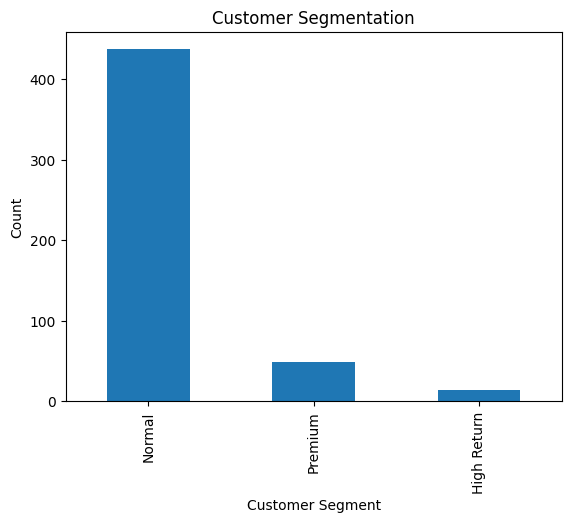

In [ ]:
df["Customer Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.show()